# Mixed precipitation publication figures

Plot saved mixed-precip NetCDFs: snow fraction by water-year day and spatial ensemble spread.

Prerequisite: run `run_process_mixed_precip.sh` to produce `{catchment}_{source}_mixed_precip.nc` files.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

workflow_dir = Path("../../").resolve()
sys.path.insert(0, str(workflow_dir / "scripts"))

from mixed_precip_publication_plot import (
    ensure_snow_fraction_wydoy_climatology,
    plot_snow_fraction_water_year_doy_publication,
)
from mixed_precip_spatial_plot import (
    plot_spatial_ensemble_spread_panel
)
from summa_postprocess_specs import DEFAULT_GPEP_ROOT, build_output_nc_manifest

# reload modules
import importlib
import mixed_precip_publication_plot
importlib.reload(mixed_precip_publication_plot)
import mixed_precip_spatial_plot
importlib.reload(mixed_precip_spatial_plot)


<module 'mixed_precip_spatial_plot' from '/home/x-dcasson/GitRepos/gpep_to_summa_snakemake/workflow/scripts/mixed_precip_spatial_plot.py'>

In [2]:
# --- Configuration ---
catchments = [
    "chena",
    "bow",
    "tuolumne",
]

gpep_root = DEFAULT_GPEP_ROOT
source_keys = ["rf", "casr", "era5"]

output_nc_by_catchment = build_output_nc_manifest(
    catchments,
    product="mixed_precip",
    gpep_root=gpep_root,
    source_keys=source_keys,
)

plot_start_year = 2010
plot_end_year = 2018


### Snow fraction by water-year day


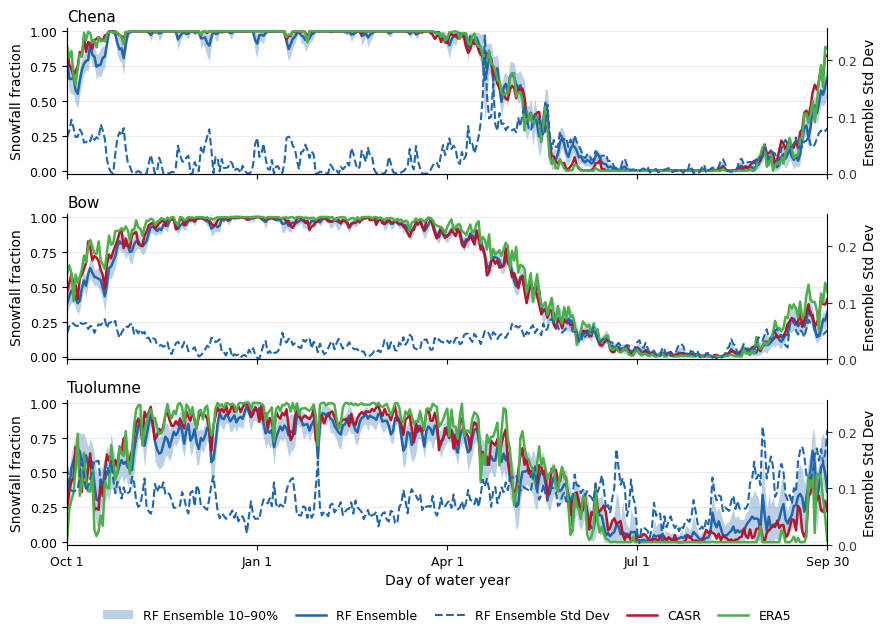

In [3]:
# Precompute once; reload from cache on later runs unless source NetCDFs change.
wydoy_cache = gpep_root / "publication_cache" / "snow_fraction_wydoy_climatology.nc"
wydoy_climatology = ensure_snow_fraction_wydoy_climatology(
    output_nc_by_catchment,
    wydoy_cache,
    catchments_list=catchments,
    wy_snowfall_start_year=plot_start_year,
    wy_snowfall_end_year=plot_end_year,
)

fig, axes = plot_snow_fraction_water_year_doy_publication(
    wydoy_climatology=wydoy_climatology,
    catchments_list=catchments,
)
plt.show()


### Spatial ensemble spread (member std dev)

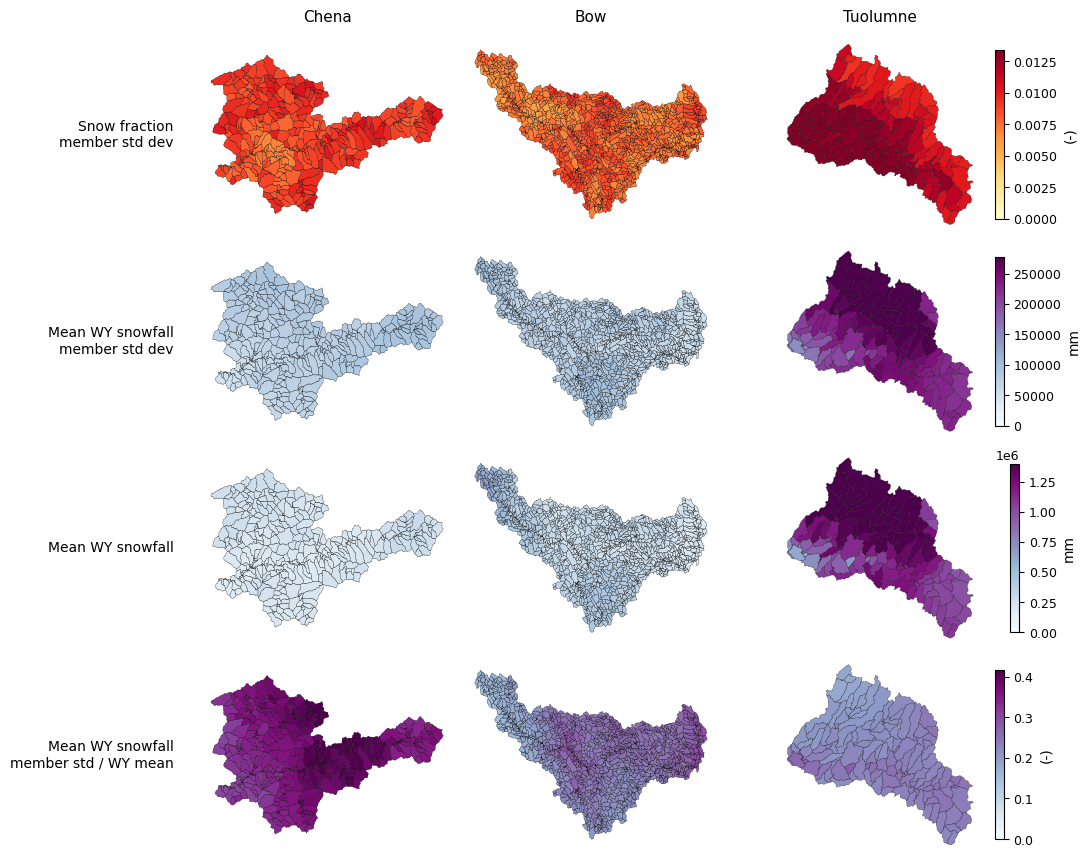

In [4]:
fig, axes, gdf_by_metric = plot_spatial_ensemble_spread_panel(
    output_nc_by_catchment,
    cache_path=wydoy_cache,
    source_label="RF Ensemble",
    catchments_list=catchments,
    gpep_root=gpep_root,
    default_start_year=plot_start_year,
    default_end_year=plot_end_year,
)
plt.show()
